# 07 — Avaliação, sampling e escalonamento (Chinchilla)

> Destila a seção 8 (Resultados) e a 2.8 (amostragem) do paper TucanoCE.
> Fecha a série: aqui medimos *quão bom* o modelo é, *como* geramos texto dele,
> e a lição de escala mais importante do projeto.

Treinar é metade; a outra metade é saber **ler o número**. Uma cross-entropy de
2,27 é boa ou ruim? O que ela diz em bits? Como transformo logits em texto sem que
o modelo entre em loop? E — a pergunta que ordena todo o roadmap — quando vale a
pena aumentar o modelo em vez de os dados?

**O que você vai sair sabendo:**
1. Interpretar cross-entropy: o piso `log(V)`, informação ganha por token, e BPC
   (bits per character) — a única métrica comparável entre tokenizers diferentes.
2. Implementar `evaluate` (loss + next-token accuracy) e por que acurácia satura antes da loss.
3. Implementar `sample_next` com temperatura, top-k, top-p e repetition penalty,
   e *ver* cada botão remodelar a distribuição.
4. Um loop `generate` autoregressivo mínimo.
5. O diagnóstico Chinchilla (`T ≈ 20·N`) e por que, neste projeto, **o gargalo é
   dado, não capacidade**.

Este notebook alimenta os stubs `src/tucanoce/training/evaluate.py` e
`src/tucanoce/inference/generate.py`.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.12.1+cpu


## 1. Interpretando a cross-entropy (paper §8.2)

O objetivo de treino é a cross-entropy autoregressiva (nb 06). Mas o valor cru
— digamos $\mathcal{L}_{val} = 2{,}27$ nats/token — não significa nada isolado.
Precisamos de referências.

**O piso trivial.** Um modelo que não aprendeu nada chuta uniforme sobre o
vocabulário: probabilidade $1/V$ para cada token. A cross-entropy disso é

$$ \mathcal{L}_{\text{trivial}} = -\log\tfrac{1}{V} = \log V. $$

Com $V = 8192$, isso é $\log 8192 \approx 9{,}01$ nats. Qualquer modelo útil fica
**abaixo** desse piso. A diferença mede **informação ganha por token** (Eq. 60):

$$ \mathcal{L}_{val} - \log V = 2{,}27 - 9{,}01 = -6{,}74 \text{ nats/token}. $$

Convertendo para bits (dividir por $\ln 2$): o modelo elimina $\approx 9{,}7$ bits
de incerteza por token em relação ao chute cego.

In [2]:
V = 8192
L_val = 2.27

floor_nats = math.log(V)
info_gain_nats = L_val - floor_nats          # negativo: reduzimos a incerteza
info_gain_bits = -info_gain_nats / math.log(2)

print(f"piso trivial log(V)      = {floor_nats:.4f} nats")
print(f"L_val                    = {L_val:.4f} nats")
print(f"informação ganha         = {info_gain_bits:.2f} bits/token")
assert floor_nats > L_val, "um modelo útil fica abaixo do piso"

piso trivial log(V)      = 9.0109 nats
L_val                    = 2.2700 nats
informação ganha         = 9.73 bits/token


**Bits per character (BPC).** A cross-entropy crua depende do tokenizer: mudar o
vocabulário muda a escala e a comparação deixa de ser justa. A métrica portável é
**bits por caractere** (Eq. 61): quantos bits o modelo gasta, em média, por
*byte* do texto original — independente de como o texto foi fatiado em tokens.

$$ \text{BPC} = \frac{\mathcal{L}_{val}}{\text{bytes\_por\_token}\cdot \ln 2}. $$

Se cada token comprime em média $\approx 4{,}65$ bytes (razão de compressão do BPE
medida no corpus, ver nb 02), então:

In [3]:
def bits_per_char(val_loss_nats: float, bytes_per_token: float) -> float:
    '''Cross-entropy (nats/token) -> bits por caractere. Portável entre tokenizers.'''
    return val_loss_nats / (bytes_per_token * math.log(2))

bpc = bits_per_char(L_val, bytes_per_token=4.65)
print(f"BPC do TucanoCE medium   = {bpc:.3f} bits/char")
print(f"BPC do GPT-2 small (ref) = 0.930 bits/char (WebText)")
assert abs(bpc - 0.71) < 0.02

BPC do TucanoCE medium   = 0.704 bits/char
BPC do GPT-2 small (ref) = 0.930 bits/char (WebText)


O modelo do paper (~43M params) atinge **BPC ≈ 0,71**, *melhor* que o GPT-2 small
(~124M params, ~0,93 BPC no WebText). Isso **não** significa que ele é melhor: o
corpus dele é Wikipedia de física — domínio muito mais estreito e previsível que
o WebText geral. Restringir o domínio facilita a tarefa. É um lembrete de que
métrica sem contexto engana: BPC só é comparável no *mesmo* tipo de dado.

## 2. Next-token accuracy — e por que ela é enganosa sozinha

`evaluate` calcula duas coisas sobre o conjunto de validação:
- **val_loss**: a cross-entropy média (o que o early stopping monitora, nb 06).
- **accuracy**: fração de posições em que o token de maior logit é o correto.

Acurácia é uma métrica *dura* (acertou/errou), menos suave que a loss. Ela satura
antes: no paper, a acurácia trava em ~54,6% enquanto a loss ainda melhora — o
modelo fica mais *calibrado* (dá mais probabilidade ao token certo) sem
necessariamente mudar qual é o argmax. Por isso a loss, e não a acurácia, guia as
decisões de treino.

Vamos montar um modelo e uma tarefa de brinquedo para exercitar a mecânica.

In [4]:
# --- Modelo de brinquedo: um mini-LM causal (1 bloco), só para exercitar avaliação/geração.
# Foco é a MECÂNICA, não qualidade de texto. Arquitetura completa vive nos nb 03/04.
class TinyLM(nn.Module):
    def __init__(self, vocab, d=32, n_heads=2, context=8):
        super().__init__()
        self.context = context
        self.n_heads = n_heads
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(context, d)      # pos-emb aprendida (estilo GPT-2, nb 03)
        self.ln1 = nn.LayerNorm(d); self.ln2 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.out = nn.Linear(d, d, bias=False)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
        self.lnf = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok.weight       # weight tying (nb 03)

    def forward(self, idx):
        B, T = idx.shape
        h = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        # atenção causal multi-head via scaled_dot_product_attention (nb 01/03)
        q, k, v = self.qkv(self.ln1(h)).chunk(3, dim=-1)
        q, k, v = (t.view(B, T, self.n_heads, -1).transpose(1, 2) for t in (q, k, v))
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        a = a.transpose(1, 2).reshape(B, T, -1)
        h = h + self.out(a)
        h = h + self.mlp(self.ln2(h))
        return self.head(self.lnf(h))            # logits (B, T, vocab)

VOCAB, CTX = 16, 8
model = TinyLM(VOCAB, context=CTX)
print("params:", sum(p.numel() for p in model.parameters()) - model.head.weight.numel())

params: 12896


In [5]:
# Tarefa de brinquedo: prever o próximo = (token + 1) % VOCAB. Aprendível e verificável.
def make_batch(bs=64):
    x = torch.randint(0, VOCAB, (bs, CTX))
    y = (x + 1) % VOCAB
    return x, y

opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
model.train()
for step in range(400):
    x, y = make_batch()
    logits = model(x)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
print(f"loss final de treino: {loss.item():.4f}  (piso trivial log(V)={math.log(VOCAB):.4f})")

loss final de treino: 0.0006  (piso trivial log(V)=2.7726)


In [6]:
@torch.no_grad()
def evaluate(model, batches):
    '''Retorna val_loss (nats/token) e next-token accuracy sobre uma lista de (x,y).'''
    model.eval()
    tot_loss, tot_correct, tot_tokens = 0.0, 0, 0
    for x, y in batches:
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1), reduction="sum")
        tot_loss += loss.item()
        tot_correct += (logits.argmax(-1) == y).sum().item()
        tot_tokens += y.numel()
    return {"val_loss": tot_loss / tot_tokens, "acc": tot_correct / tot_tokens}

val_batches = [make_batch(128) for _ in range(5)]
metrics = evaluate(model, val_batches)
print(f"val_loss = {metrics['val_loss']:.4f} nats/token")
print(f"accuracy = {metrics['acc']:.1%}")
print(f"bits ganhos vs piso = {(math.log(VOCAB) - metrics['val_loss'])/math.log(2):.2f} bits/token")

val_loss = 0.0006 nats/token
accuracy = 100.0%
bits ganhos vs piso = 4.00 bits/token


O modelo aprendeu a regra: loss bem abaixo do piso e acurácia alta. Numa tarefa
real de linguagem, a acurácia satura antes da loss — mas a mecânica de medir é
exatamente esta. É o que vai no stub `evaluate.py`.

### Lendo uma curva de treino real: a assinatura do *overfitting*

A Tabela 1 do paper traz a curva completa do treino do `medium` (43M) sobre 12,5M
tokens. Plotada, ela mostra o padrão que o *early stopping* (nb 06) existe para
capturar: a **train loss cai monotonicamente**, mas a **val loss** para de melhorar
no *epoch* 8 e depois **vira para cima**. A partir daí o modelo está memorizando o
treino em vez de generalizar — é o **overfitting**. O checkpoint salvo é o do
melhor `val_loss` (epoch 8), não o do último epoch.

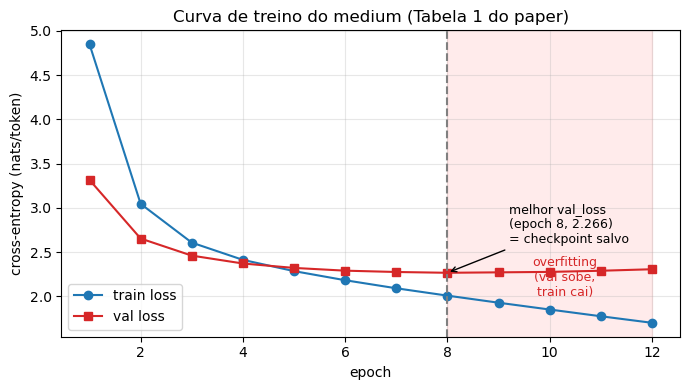

train loss: cai de 4.85 a 1.70 (monotônico)
val loss  : mínimo 2.266 no epoch 8, depois SOBE -> overfitting
early stopping salvaria o epoch 8 e pararia por volta do 12 (patience=4)


In [7]:
import matplotlib.pyplot as plt

# Dados reais da Tabela 1 do paper (medium, 43M, corpus 12,5M tokens).
epochs    = list(range(1, 13))
train_loss = [4.848, 3.045, 2.607, 2.412, 2.285, 2.182, 2.091, 2.008, 1.928, 1.851, 1.775, 1.701]
val_loss   = [3.315, 2.653, 2.460, 2.371, 2.321, 2.290, 2.275, 2.266, 2.271, 2.276, 2.289, 2.306]
best = int(np.argmin(val_loss))            # índice do melhor val_loss

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, train_loss, "o-", label="train loss", color="#1f77b4")
ax.plot(epochs, val_loss, "s-", label="val loss", color="#d62728")
ax.axvline(epochs[best], ls="--", color="gray")
ax.annotate(f"melhor val_loss\n(epoch {epochs[best]}, {val_loss[best]:.3f})\n= checkpoint salvo",
            xy=(epochs[best], val_loss[best]), xytext=(epochs[best] + 1.2, 2.6),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.axvspan(epochs[best], epochs[-1], alpha=0.08, color="red")
ax.text(10.3, 2.0, "overfitting\n(val sobe,\ntrain cai)", color="#d62728", fontsize=9, ha="center")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy (nats/token)")
ax.set_title("Curva de treino do medium (Tabela 1 do paper)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"train loss: cai de {train_loss[0]:.2f} a {train_loss[-1]:.2f} (monotônico)")
print(f"val loss  : mínimo {val_loss[best]:.3f} no epoch {epochs[best]}, depois SOBE -> overfitting")
print("early stopping salvaria o epoch 8 e pararia por volta do 12 (patience=4)")

## 3. Sampling: transformando logits em texto (paper §2.8)

Na geração, a última posição produz logits sobre o vocabulário. Como escolher o
próximo token? Amostrar da distribuição, mas com controle. Quatro botões:

- **Temperatura $\tau$** (Eq. 16): divide os logits antes do softmax.
  $\tau \to 0$ colapsa no *argmax* (texto previsível, repetitivo); $\tau$ alto
  achata a distribuição (mais variedade, risco de incoerência).
- **top-k**: mantém só os $k$ tokens mais prováveis, zera o resto. Corta a cauda.
- **top-p (nucleus)**: mantém o menor conjunto cuja probabilidade acumulada
  atinge $p$. Adaptativo — o tamanho do conjunto varia com a confiança do modelo.
- **repetition penalty**: penaliza tokens já emitidos, combatendo loops.

A ordem importa: penalidade de repetição → temperatura → top-k → top-p → softmax
→ amostragem.

In [8]:
def sample_next(logits, temperature=1.0, top_k=None, top_p=None,
                repetition_penalty=1.0, prev_tokens=None, generator=None):
    '''logits: (vocab,). Retorna id amostrado (int). Ordem: rep-penalty -> temp -> top-k -> top-p.'''
    logits = logits.clone().float()

    # repetition penalty (estilo CTRL): empurra tokens já vistos para baixo
    if repetition_penalty != 1.0 and prev_tokens is not None:
        for t in set(prev_tokens):
            logits[t] = logits[t] / repetition_penalty if logits[t] > 0 else logits[t] * repetition_penalty

    if temperature <= 0:                         # temperatura 0 = argmax determinístico
        return int(logits.argmax())
    logits = logits / temperature

    if top_k is not None:                        # zera tudo fora dos k maiores
        kth = torch.topk(logits, top_k).values[-1]
        logits[logits < kth] = float("-inf")

    if top_p is not None:                         # nucleus: menor conjunto com massa >= p
        s_logits, s_idx = torch.sort(logits, descending=True)
        cum = torch.softmax(s_logits, dim=-1).cumsum(dim=-1)
        remove = cum > top_p
        remove[..., 1:] = remove[..., :-1].clone()   # mantém sempre o 1º token
        remove[..., 0] = False
        logits[s_idx[remove]] = float("-inf")

    probs = torch.softmax(logits, dim=-1)
    return int(torch.multinomial(probs, 1, generator=generator))

In [9]:
# Demonstração: como cada botão remodela a MESMA distribuição de logits.
logits = torch.tensor([3.0, 2.5, 2.0, 0.5, 0.2, -1.0, -2.0, -3.0])
def show(name, probs):
    print(f"{name:22s} " + " ".join(f"{p:5.2f}" for p in probs))

show("logits (raw)", logits)
show("softmax tau=1.0", torch.softmax(logits, -1))
show("softmax tau=0.5", torch.softmax(logits / 0.5, -1))   # mais afiada
show("softmax tau=2.0", torch.softmax(logits / 2.0, -1))   # mais achatada

# top-k=3: só os 3 maiores sobrevivem
lk = logits.clone(); lk[lk < torch.topk(lk, 3).values[-1]] = float("-inf")
show("top-k=3", torch.softmax(lk, -1))

# top-p=0.7: menor núcleo com massa acumulada >= 0.7
s, idx = torch.sort(logits, descending=True)
cum = torch.softmax(s, -1).cumsum(-1); rem = cum > 0.7
rem[1:] = rem[:-1].clone(); rem[0] = False
lp = logits.clone(); lp[idx[rem]] = float("-inf")
show("top-p=0.7", torch.softmax(lp, -1))

logits (raw)            3.00  2.50  2.00  0.50  0.20 -1.00 -2.00 -3.00
softmax tau=1.0         0.47  0.28  0.17  0.04  0.03  0.01  0.00  0.00
softmax tau=0.5         0.66  0.24  0.09  0.00  0.00  0.00  0.00  0.00
softmax tau=2.0         0.31  0.24  0.19  0.09  0.08  0.04  0.03  0.02
top-k=3                 0.51  0.31  0.19  0.00  0.00  0.00  0.00  0.00
top-p=0.7               0.62  0.38  0.00  0.00  0.00  0.00  0.00  0.00


Leia as linhas: `tau=0.5` concentra massa no topo (mais determinístico);
`tau=2.0` espalha (mais aleatório); `top-k=3` e `top-p=0.7` zeram a cauda, cada um
por um critério diferente (contagem fixa vs. massa acumulada). Na prática o paper
gerou com `temp=0.8, top-k=40` e usou `repetition_penalty=1.2` para escapar de
loops — combinar temperatura moderada com corte de cauda é o padrão.

As barras abaixo mostram os quatro botões agindo na **mesma** distribuição. Repare:
a temperatura redistribui a massa entre *todos* os tokens (nada zera); top-k e top-p
**zeram** parte da cauda (barras somem) — top-k por contagem fixa, top-p por massa
acumulada. As barras cinzas de fundo são a distribuição original, para comparação.

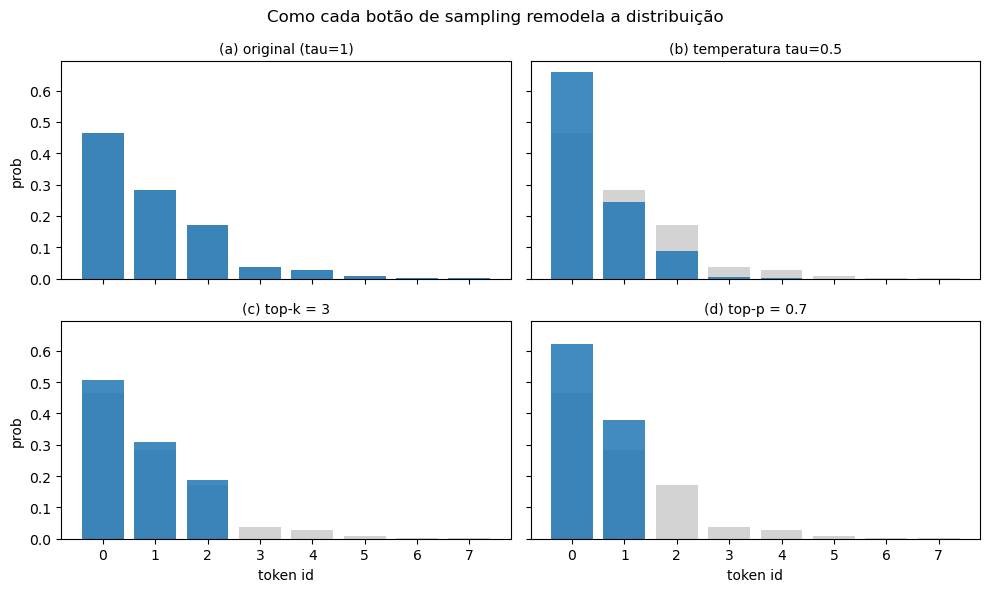

In [10]:
# Reaproveita logits, lk (top-k) e lp (top-p) já computados acima.
p_raw  = torch.softmax(logits, -1).numpy()
p_temp = torch.softmax(logits / 0.5, -1).numpy()
p_topk = torch.softmax(lk, -1).numpy()
p_topp = torch.softmax(lp, -1).numpy()
idxs = np.arange(len(logits))

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
for ax, (title, p) in zip(axes.ravel(), [
        ("(a) original (tau=1)", p_raw), ("(b) temperatura tau=0.5", p_temp),
        ("(c) top-k = 3", p_topk), ("(d) top-p = 0.7", p_topp)]):
    ax.bar(idxs, p_raw, color="lightgray", label="original")  # sombra de referência
    ax.bar(idxs, p, color="C0", alpha=0.85)
    ax.set_title(title, fontsize=10)
axes[1, 0].set_xlabel("token id"); axes[1, 1].set_xlabel("token id")
axes[0, 0].set_ylabel("prob"); axes[1, 0].set_ylabel("prob")
fig.suptitle("Como cada botão de sampling remodela a distribuição")
plt.tight_layout(); plt.show()

## 4. Geração autoregressiva

O loop é simples: alimenta o contexto, pega os logits da **última** posição,
amostra o próximo token, concatena, repete. A versão abaixo recomputa o forward
inteiro a cada passo — custo $O(N^2)$ no comprimento gerado. O **nb 04** mostra a
versão com **KV-cache**, que reaproveita $K,V$ já calculados e derruba o custo
para $O(N)$; a mecânica de amostragem é idêntica.

In [11]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=12, temperature=0.8, top_k=8,
             top_p=None, repetition_penalty=1.2, generator=None):
    model.eval()
    ids = list(prompt)
    for _ in range(max_new_tokens):
        ctx = torch.tensor([ids[-model.context:]])       # janela de contexto
        logits = model(ctx)[0, -1]                        # logits da última posição
        nxt = sample_next(logits, temperature, top_k, top_p,
                          repetition_penalty, prev_tokens=ids, generator=generator)
        ids.append(nxt)
    return ids

g = torch.Generator().manual_seed(0)
out = generate(model, prompt=[5], max_new_tokens=10, generator=g)
print("prompt: [5]")
print("gerado:", out)
# o modelo brinquedo aprendeu 'próximo = (x+1)%V', então a continuação deve incrementar
print("regra aprendida (incrementar +1 mod 16):", out == [(5 + i) % VOCAB for i in range(len(out))])

prompt: [5]
gerado: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
regra aprendida (incrementar +1 mod 16): True


O modelo brinquedo continua a sequência incrementando — exatamente a regra que
treinamos. É o esqueleto de `inference/generate.py`: contexto → logits → sample →
concatena. Trocar `TinyLM` pelo `TucanoCE` real (nb 03/04) e ligar o KV-cache é o
que falta para a inferência de produção.

## 5. Escalonamento: o diagnóstico Chinchilla (paper §8.5–8.6)

Aqui está a lição de maior valor do projeto. Hoffmann et al. (2022, "Chinchilla")
derivaram empiricamente que o ótimo de *compute* para um LM ocorre quando

$$ T^* \approx 20 \cdot N, $$

com $T$ = tokens de treino e $N$ = parâmetros. A razão $T/N$ diagnostica o regime:

- $T/N \ll 20$: **compute constrained** — parâmetros demais para o volume de dados.
- $T/N \gg 20$: **data constrained** — dados demais para o tamanho do modelo.

O paper rodou um par de experimentos *controlados* que valem ouro:

In [12]:
import pandas as pd  # se não houver pandas, ver célula alternativa abaixo

exp = pd.DataFrame([
    # modelo,          N (M), tokens (M), L_val,  BPC,   observação
    ("medium v2",      42.7,  12.5,       2.266,  0.719, "baseline"),
    ("large v1",       91.2,  12.5,       2.278,  0.723, "2x params, MESMO corpus"),
    ("xl",            210.8,  25.3,       2.155,  None,  "4.9x params, corpus 2x"),
    ("medium v3",      42.7,  25.3,       2.132,  0.677, "MESMO modelo, corpus 2x"),
], columns=["modelo", "N_M", "tokens_M", "L_val", "BPC", "obs"])
exp["T/N"] = (exp["tokens_M"] / exp["N_M"]).round(2)
print(exp.to_string(index=False))

   modelo   N_M  tokens_M  L_val   BPC                     obs  T/N
medium v2  42.7      12.5  2.266 0.719                baseline 0.29
 large v1  91.2      12.5  2.278 0.723 2x params, MESMO corpus 0.14
       xl 210.8      25.3  2.155   NaN  4.9x params, corpus 2x 0.12
medium v3  42.7      25.3  2.132 0.677 MESMO modelo, corpus 2x 0.59


Leia a tabela pela ótica dos pares controlados:

1. **`medium v2` → `large v1`**: dobrar os parâmetros (43M → 91M) com o **mesmo
   corpus** de 12,5M tokens **não** moveu o teto (`L_val` 2,266 → 2,278; até piorou
   de leve). Capacidade extra não vira qualidade quando os dados não crescem.
2. **`medium v2` → `medium v3`**: dobrar os **dados** (12,5M → 25,3M tokens) com o
   **mesmo modelo** derrubou `L_val` de 2,266 para 2,132 (−5,9%) e subiu BPC.
3. O golpe final: **`medium v3` (43M) supera `xl` (211M)** no mesmo corpus de
   25,3M tokens. Um modelo 4,9× menor vence — porque tem dados na proporção certa.

> **O gargalo é dado, não capacidade.** Dobrar os dados moveu o teto; multiplicar
> o modelo por ~5× não. É o argumento Chinchilla na forma mais direta que os
> recursos do projeto permitem demonstrar.

Todos os modelos do projeto estão em $T/N \ll 20$ — ordens de magnitude abaixo do
ótimo. Vamos ver isso nos presets de arquitetura.

A figura torna o par controlado visível de um golpe: **menor barra = melhor**.
`medium v3` (43M, corpus 2×) tem o **menor** `val_loss` — abaixo de `large` (91M) e
de `xl` (211M). As cores separam por corpus: dobrar os **dados** (barras do corpus
25,3M) derruba o teto; dobrar os **parâmetros** dentro do mesmo corpus, não.

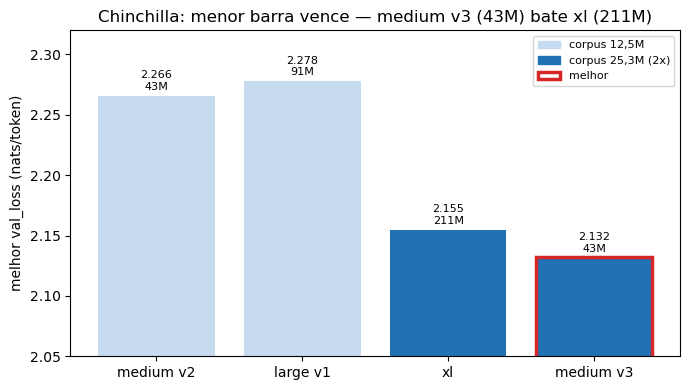

In [13]:
# Reaproveita o DataFrame `exp` da célula anterior.
labels = exp["modelo"].tolist()
vals   = exp["L_val"].tolist()
# cor por corpus: 12,5M vs 25,3M (corpus 2x)
colors = ["#c6dbef" if t == 12.5 else "#2171b5" for t in exp["tokens_M"]]
best_i = int(np.argmin(vals))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, vals, color=colors)
bars[best_i].set_edgecolor("#d62728"); bars[best_i].set_linewidth(2.5)
for b, v, n in zip(bars, vals, exp["N_M"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.003, f"{v:.3f}\n{n:.0f}M",
            ha="center", va="bottom", fontsize=8)
ax.set_ylim(2.05, 2.32); ax.set_ylabel("melhor val_loss (nats/token)")
ax.set_title("Chinchilla: menor barra vence — medium v3 (43M) bate xl (211M)")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1,color="#c6dbef"), plt.Rectangle((0,0),1,1,color="#2171b5"),
    plt.Rectangle((0,0),1,1,fill=False,edgecolor="#d62728",lw=2.5)],
    labels=["corpus 12,5M", "corpus 25,3M (2x)", "melhor"], fontsize=8)
plt.tight_layout(); plt.show()

In [14]:
# Estima params de um modelo estilo LLaMA (RMSNorm/SwiGLU/RoPE, weight tying) por preset,
# e o T/N contra um corpus hipotético — para enxergar a distância do ótimo Chinchilla (~20).
def hidden_dim(d, multiple_of=64):
    h = int(8 * d / 3)
    return ((h + multiple_of - 1) // multiple_of) * multiple_of

def est_params(d, L, vocab=8192):
    emb   = vocab * d                     # embedding (compartilhada com lm_head via weight tying)
    attn  = L * (4 * d * d)               # q,k,v,out projections (sem bias)
    h     = hidden_dim(d)
    mlp   = L * (3 * d * h)               # gate, up, down (SwiGLU)
    norms = L * 2 * d + d                 # RMSNorm (gammas) + norm final
    return emb + attn + mlp + norms

PRESETS = {"small": (128, 6), "base": (256, 8), "medium": (512, 12),
           "large": (768, 12), "xl": (1024, 16)}
CORPUS_TOKENS = 25_300_000                # corpus v3 do paper

print(f"{'preset':7s} {'d':>5} {'L':>3} {'N (M)':>8} {'T/N':>7} {'regime':>18}")
for name, (d, L) in PRESETS.items():
    N = est_params(d, L)
    tn = CORPUS_TOKENS / N
    regime = "compute constrained" if tn < 20 else "data constrained"
    print(f"{name:7s} {d:>5} {L:>3} {N/1e6:>8.1f} {tn:>7.2f} {regime:>19}")
print(f"\notimo Chinchilla: T/N ~ 20  |  para o 'medium' atingir isso, precisaria de ~{est_params(512,12)*20/1e9:.1f}B tokens")

preset      d   L    N (M)     T/N             regime
small     128   6      2.3   10.87 compute constrained
base      256   8      8.5    2.97 compute constrained
medium    512  12     42.7    0.59 compute constrained
large     768  12     91.2    0.28 compute constrained
xl       1024  16    210.8    0.12 compute constrained

otimo Chinchilla: T/N ~ 20  |  para o 'medium' atingir isso, precisaria de ~0.9B tokens


Em escala log, a distância do ótimo salta aos olhos: a linha tracejada é
$T/N = 20$ (Chinchilla); **todas** as barras ficam ordens de magnitude abaixo — o
projeto inteiro é *compute constrained*. Quanto maior o modelo, mais fundo o buraco
(menos tokens por parâmetro), reforçando: no regime atual, mais dados > mais params.

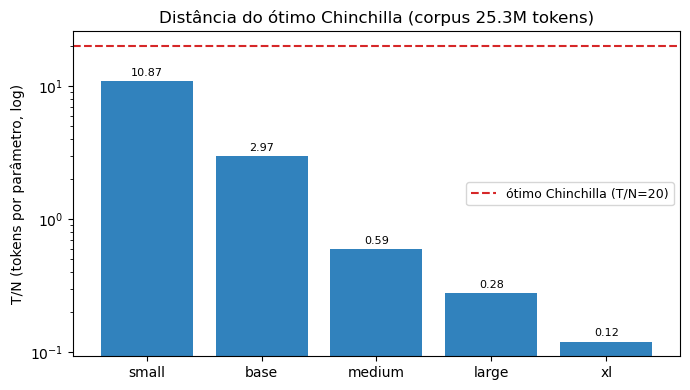

In [15]:
# Recalcula T/N por preset (reaproveitando est_params/PRESETS/CORPUS_TOKENS).
names = list(PRESETS)
tns   = [CORPUS_TOKENS / est_params(*PRESETS[n]) for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, tns, color="#3182bd")
ax.axhline(20, ls="--", color="#d62728", lw=1.5, label="ótimo Chinchilla (T/N=20)")
ax.set_yscale("log")
for b, t in zip(bars, tns):
    ax.text(b.get_x()+b.get_width()/2, t*1.1, f"{t:.2f}", ha="center", fontsize=8)
ax.set_ylabel("T/N (tokens por parâmetro, log)")
ax.set_title(f"Distância do ótimo Chinchilla (corpus {CORPUS_TOKENS/1e6:.1f}M tokens)")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

Todos os presets ficam muito abaixo de `T/N ≈ 20` com este corpus — são
*compute constrained*. A conclusão prática (e o que ordena o roadmap na
`ARCHITECTURE.md`): **a próxima alavanca é dado, não parâmetro**. Escalar o modelo
antes de escalar o corpus é desperdício de compute.

## Resumo (o que fecha a série)

| Peça | O que faz | Stub que alimenta |
|---|---|---|
| `bits_per_char` | cross-entropy → BPC (portável entre tokenizers) | `training/evaluate.py` |
| `evaluate` | val_loss (nats/token) + next-token accuracy | `training/evaluate.py` |
| `sample_next` | temperatura, top-k, top-p, repetition penalty | `inference/generate.py` |
| `generate` | loop autoregressivo (KV-cache no nb 04) | `inference/generate.py` |
| diagnóstico `T/N` | regime Chinchilla; dado vs capacidade | roadmap (`ARCHITECTURE.md`) |

**Caminho de evolução:** o paper Chinchilla (Hoffmann et al., 2022) para a lei de
escala; e, como ferramenta, `lm-evaluation-harness` (EleutherAI) para trocar
"loss em held-out" por benchmarks estruturados (HellaSwag, ARC, MMLU) — o próximo
passo de avaliação citado na seção 9.

**Fim da série (00 → 07).** Agora o exercício: preencha os stubs em `src/tucanoce/`
a partir do que cada notebook derivou. Ao terminar, `src/` vira um LM treinável —
escrito por você.